In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = fetch_california_housing()
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
df = pd.DataFrame(data=data['data'],columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
df['Price'] = data['target']

In [6]:
len(df.columns)

9

In [7]:
df.columns[0]

'MedInc'

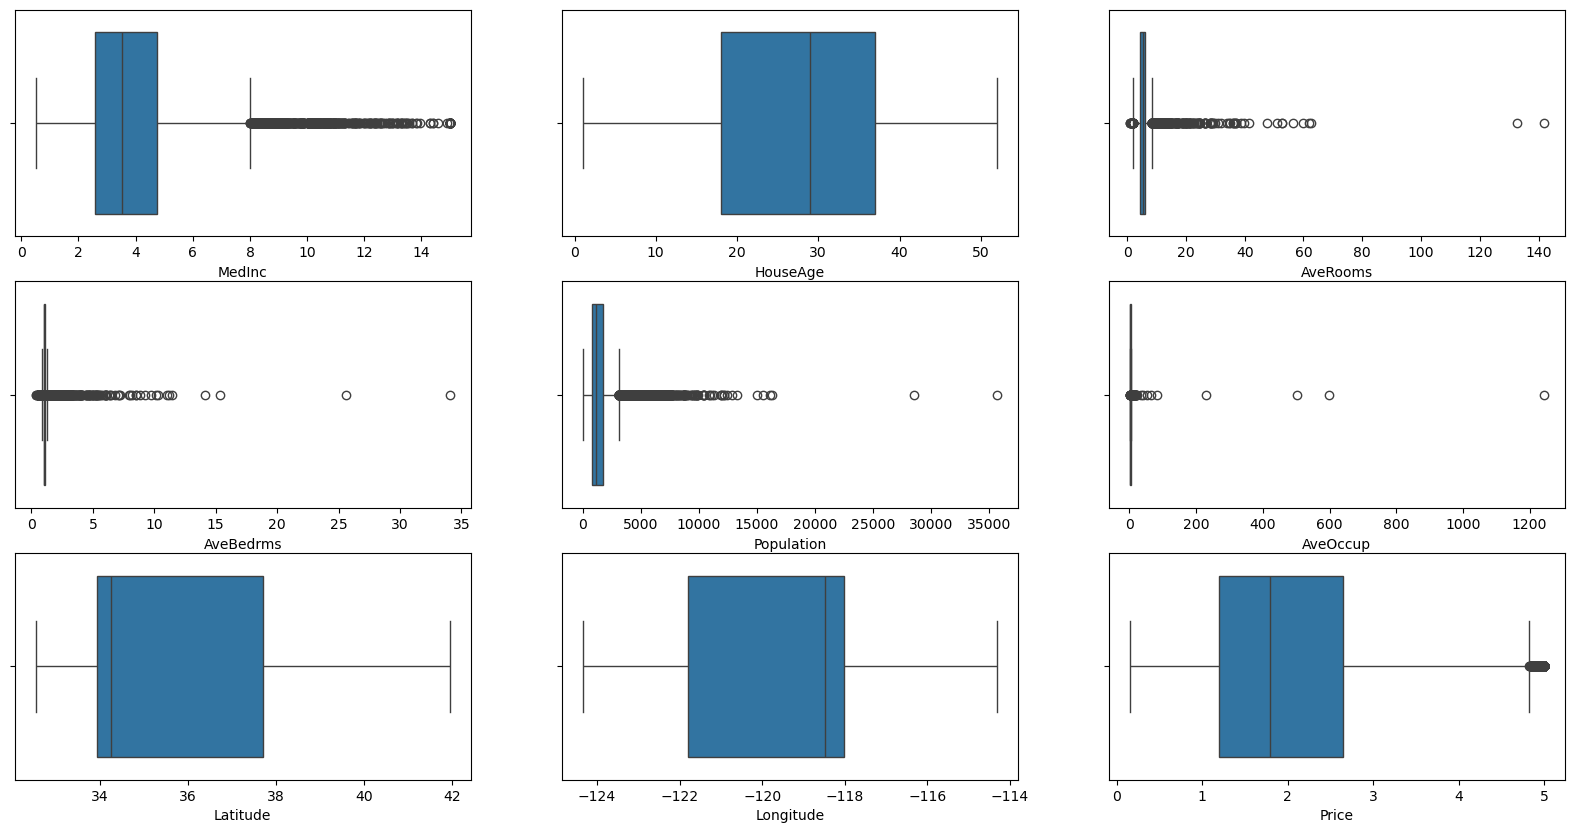

In [8]:
plt.figure(figsize=(20,10))
for i in range(len(df.columns)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[df.columns[i]])

In [9]:
Columns = df.columns
Columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

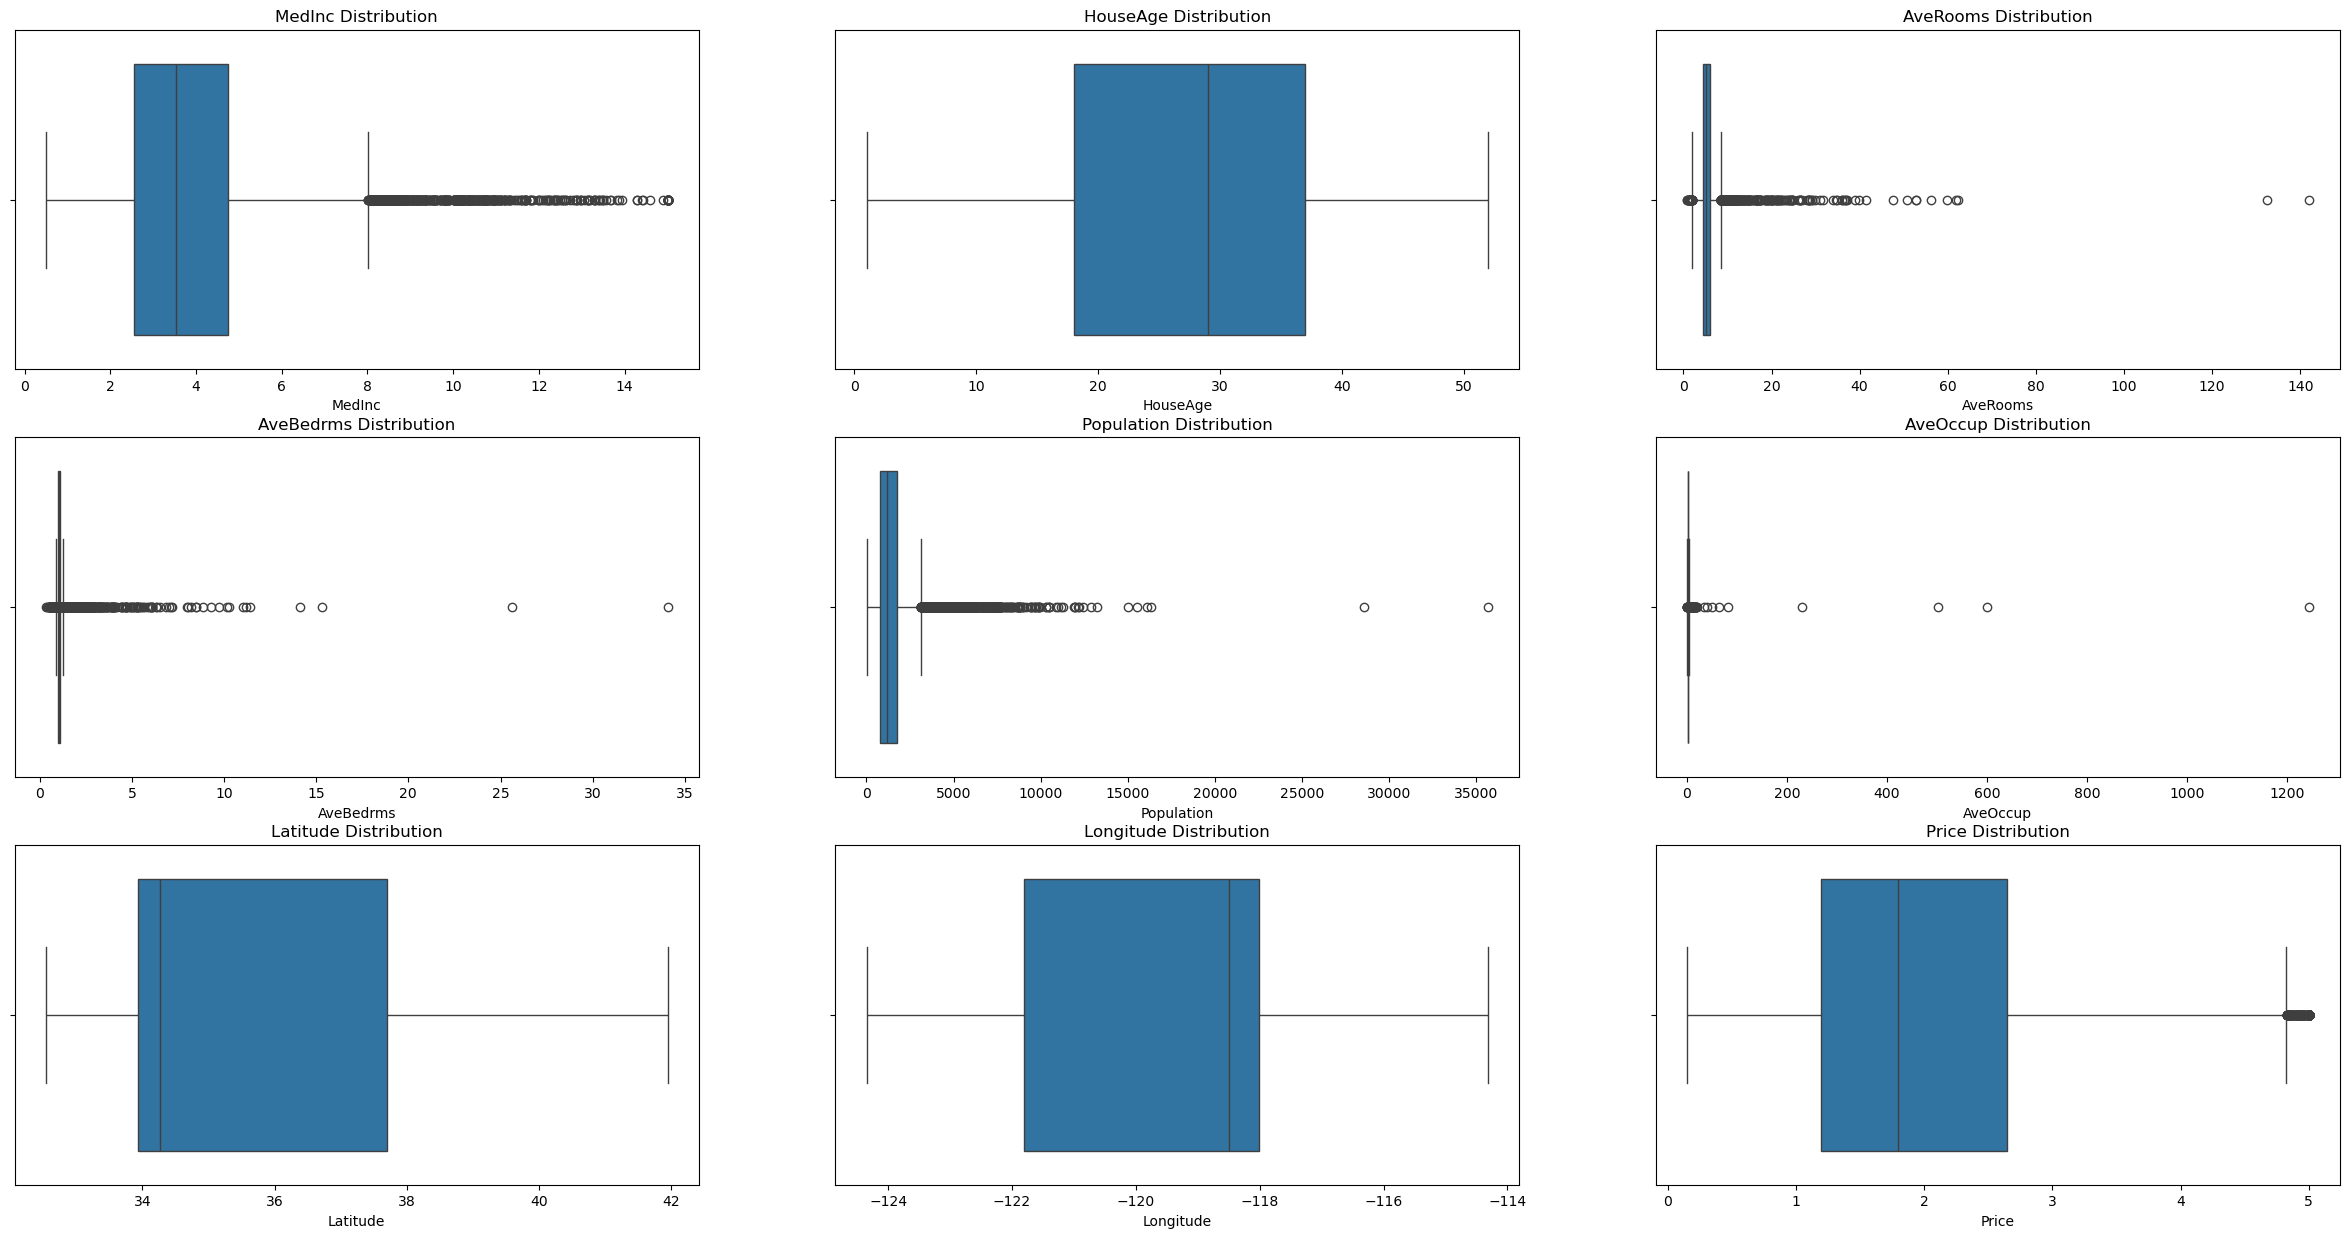

In [10]:
plt.figure(figsize=(30,15))
for i in range(len(Columns)):
    plt.subplot(3,3,i+1)
    plt.title(f"{Columns[i]} Distribution")
    sns.boxplot(x=df[Columns[i]])

In [11]:
df['MedInc']

0        8.3252
1        8.3014
2        7.2574
3        5.6431
4        3.8462
          ...  
20635    1.5603
20636    2.5568
20637    1.7000
20638    1.8672
20639    2.3886
Name: MedInc, Length: 20640, dtype: float64

<Axes: xlabel='MedInc'>

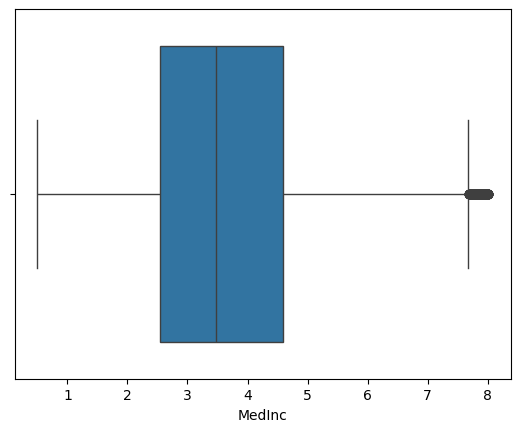

In [12]:
Q1 = df['MedInc'].quantile(0.25)
Q3 = df['MedInc'].quantile(0.75)

IQR = Q3 - Q1


Lower_bound = Q1 - (1.5 * IQR)
Upper_bound = Q3 + (1.5 * IQR)

Lower_bound , Upper_bound,IQR

df_outlier_removed = df[(df['MedInc'] >= Lower_bound) & (df['MedInc'] <= Upper_bound)]
sns.boxplot(x='MedInc',data=df_outlier_removed)

In [24]:
def outlier_removed():
    df_clean = df.copy()
    for i in df.columns:
        Q1 = df[i].quantile(0.25)
        Q3 = df[i].quantile(0.75)
        IQR = Q3 - Q1
        Lower_bound = Q1 - (1.5 * IQR)
        Upper_bound = Q3 + (1.5 * IQR)
        df_clean = df_clean[(df_clean[i] >= Lower_bound) & (df_clean[i] <= Upper_bound)]
    return df_clean
df_clean =  outlier_removed()

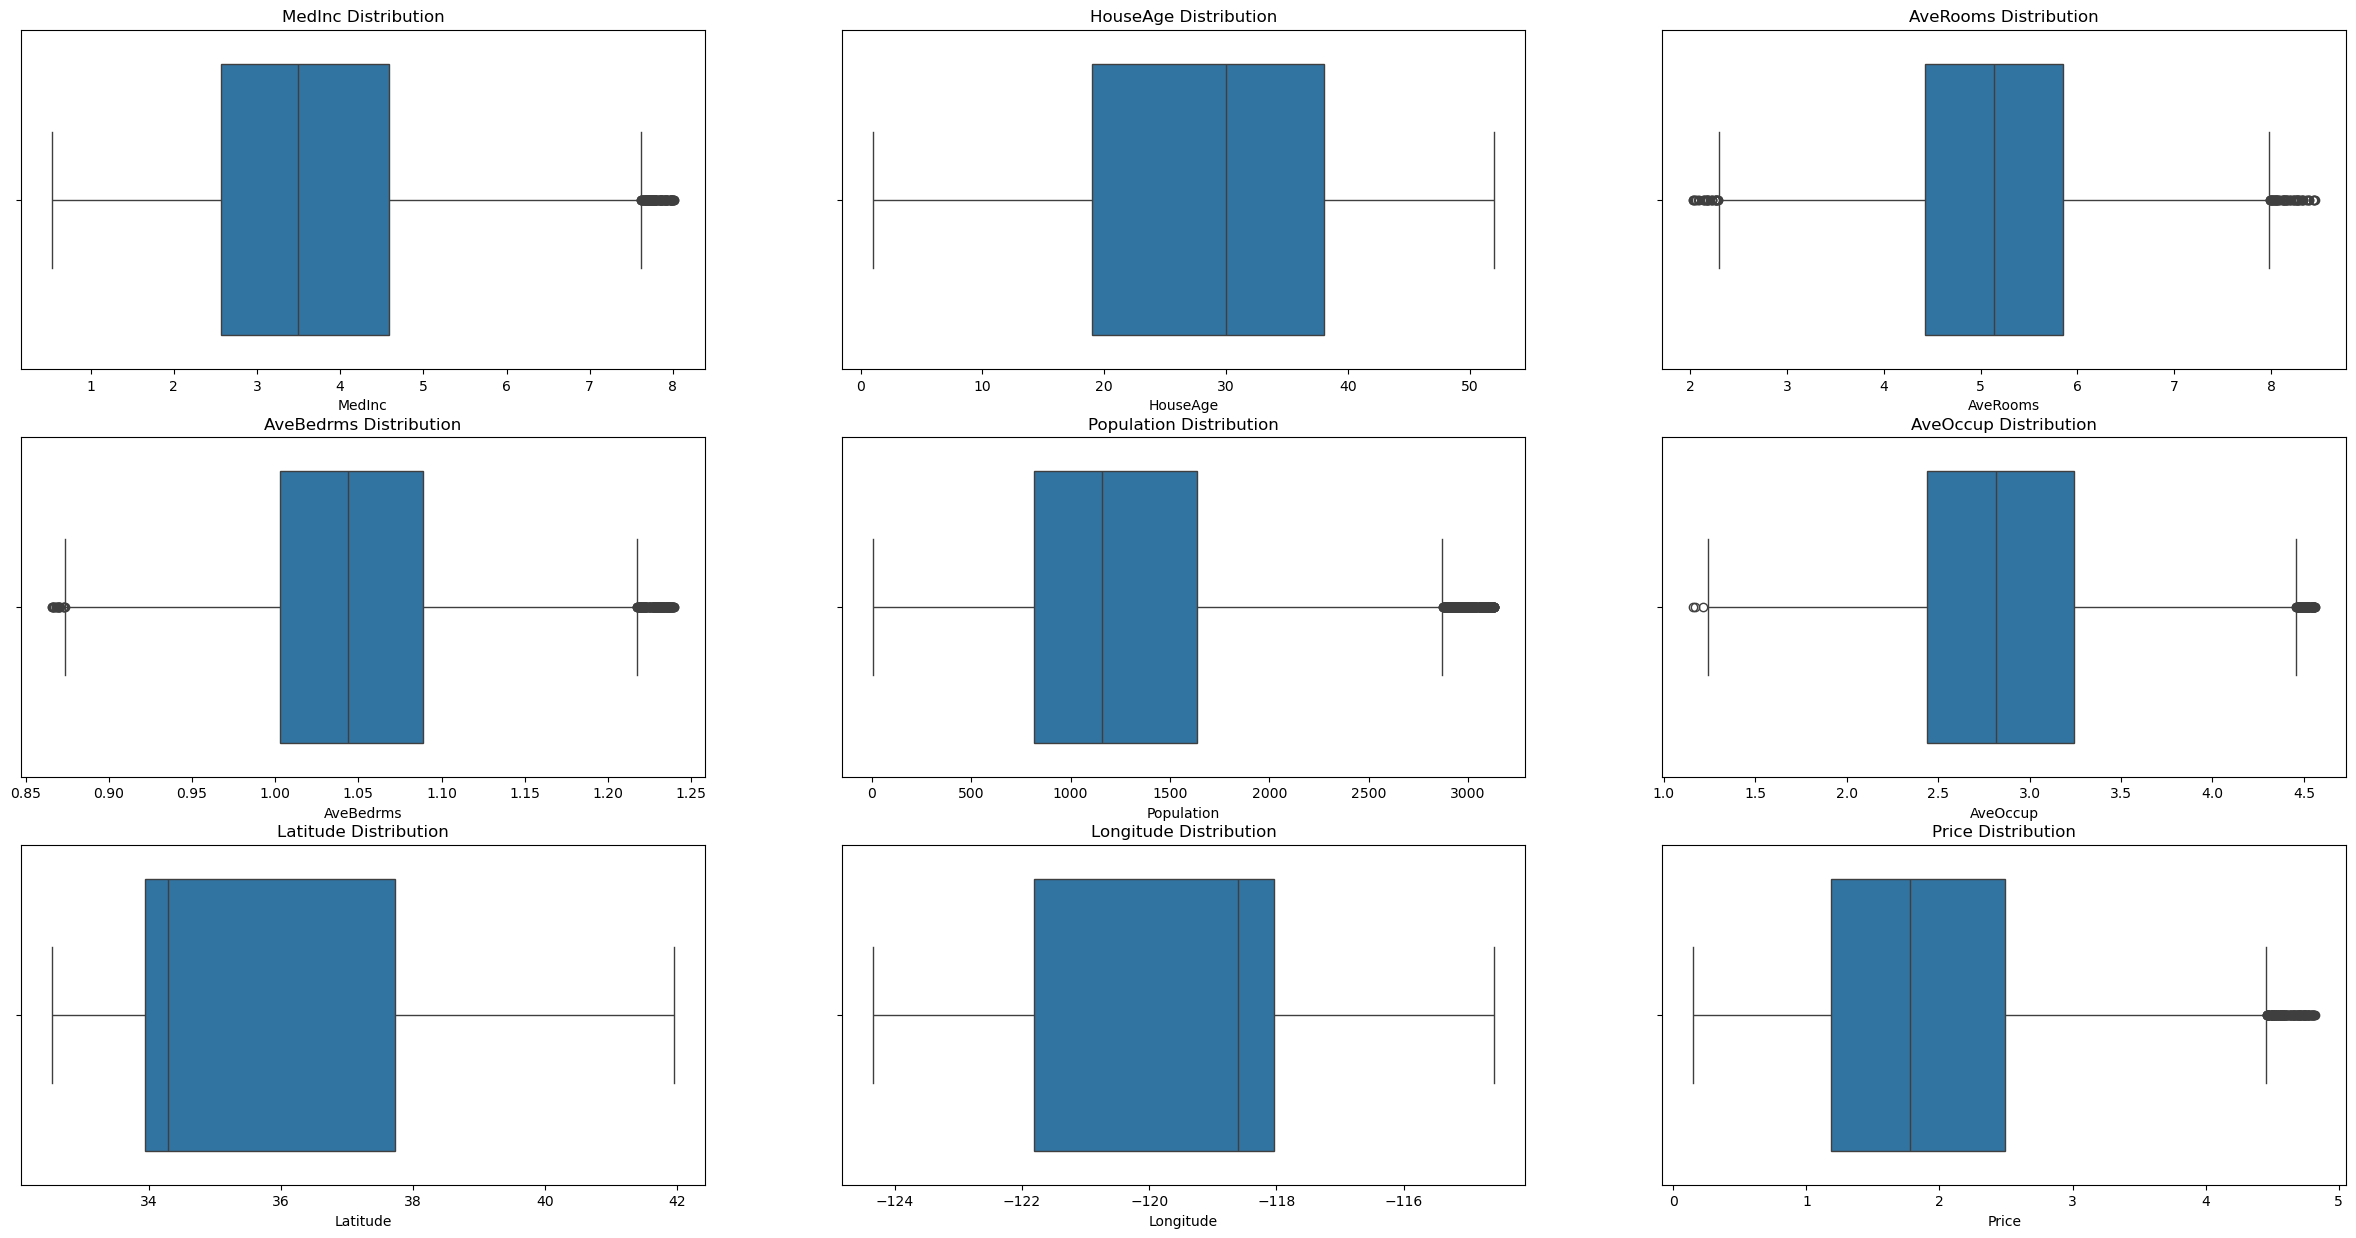

In [25]:
plt.figure(figsize=(30,15))
for i in range(len(Columns)):
    plt.subplot(3,3,i+1)
    plt.title(f"{Columns[i]} Distribution")
    sns.boxplot(x=Columns[i],data=df_clean)